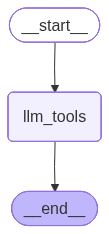

In [2]:
def add(a:int,b:int)->int:
    """ Docstring for add
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a+b


from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage,AIMessage,AnyMessage
from IPython.display import display,Image

llm = ChatOpenAI(model="gpt-4o-mini")

llm_tool = llm.bind_tools([add])

initial_message = [AIMessage(content="Hi How can I help you",name='llmmodel')]
initial_message.append(HumanMessage(content="I want to learn programming",name='harika'))

aimessage = AIMessage(content="Which programming language do you want to learn",name='llmmodel')


add_messages(initial_message,aimessage)


class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

def llm_tools(state:State):
    return {"messages":[llm_tool.invoke(state['messages'])]}


builder = StateGraph(State)

builder.add_node('llm_tools',llm_tools)
builder.add_edge(START,'llm_tools')
builder.add_edge('llm_tools',END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [3]:
from langchain_core.messages import HumanMessage

messages = graph.invoke({"messages":"What is 2+2"})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

What is 2+2
================================== Ai Message ==================================
Tool Calls:
  add (call_GhdYa8RdM0uwkcF8HchynlDz)
 Call ID: call_GhdYa8RdM0uwkcF8HchynlDz
  Args:
    a: 2
    b: 2
